# Module 0
Explore and analyse the dataset to understand its structure and key characteristics (describe
them); Conduct data pre-processing (i.e., encoding categorical variables, feature scaling,
missing values imputation); Create new variables if needed.

In [28]:
import pandas as pd

df = pd.read_csv('data/cmi_internet.csv')
df

,id,Basic_Demos-Enroll_Season,Basic_Demos-Age,Basic_Demos-Sex,CGAS-Season,CGAS-CGAS_Score,Physical-Season,Physical-BMI,Physical-Height,Physical-Weight,...,PCIAT-PCIAT_18,PCIAT-PCIAT_19,PCIAT-PCIAT_20,PCIAT-PCIAT_Total,SDS-Season,SDS-SDS_Total_Raw,SDS-SDS_Total_T,PreInt_EduHx-Season,PreInt_EduHx-computerinternet_hoursday,sii
0,0,Fall,5,0,Winter,51.0,Fall,16.877316,46.00,50.8,...,4.0,2.0,4.0,55.0,NaN,NaN,NaN,Fall,3.0,2.0
1,1,Summer,9,0,NaN,NaN,Fall,14.035590,48.00,46.0,...,0.0,0.0,0.0,0.0,Fall,46.0,64.0,Summer,0.0,0.0
2,2,Summer,10,1,Fall,71.0,Fall,16.648696,56.50,75.6,...,2.0,1.0,1.0,28.0,Fall,38.0,54.0,Summer,2.0,0.0
3,3,Winter,9,0,Fall,71.0,Summer,18.292347,56.00,81.6,...,3.0,4.0,1.0,44.0,Summer,31.0,45.0,Winter,0.0,1.0
4,4,Spring,18,1,Summer,65.0,NaN,17.937682,NaN,77.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Spring,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8455,8455,Spring,7,1,Spring,NaN,Fall,16.130585,46.07,49.0,...,NaN,NaN,NaN,NaN,Summer,38.5,55.0,Spring,0.0,0.0
8456,8456,Winter,10,1,Spring,69.5,Winter,NaN,56.13,47.8,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Winter,0.0,1.0
8457,8457,Winter,10,1,Winter,70.0,Winter,40.937571,49.56,47.2,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Spring,2.0,0.0
8458,8458,Fall,15,1,NaN,55.5,Spring,NaN,63.79,99.5,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Fall,1.0,2.0


In [24]:
# Convert imperial units to metric
df['Physical-Height'] = df['Physical-Height'] * 2.54            # inches → cm
df['Physical-Weight'] = df['Physical-Weight'] * 0.453592        # lbs → kg
df['Physical-Waist_Circumference'] = df['Physical-Waist_Circumference'] * 2.54  # inches → cm

print("Converted Height (in→cm), Weight (lbs→kg), Waist Circumference (in→cm)")

Converted Height (in→cm), Weight (lbs→kg), Waist Circumference (in→cm)


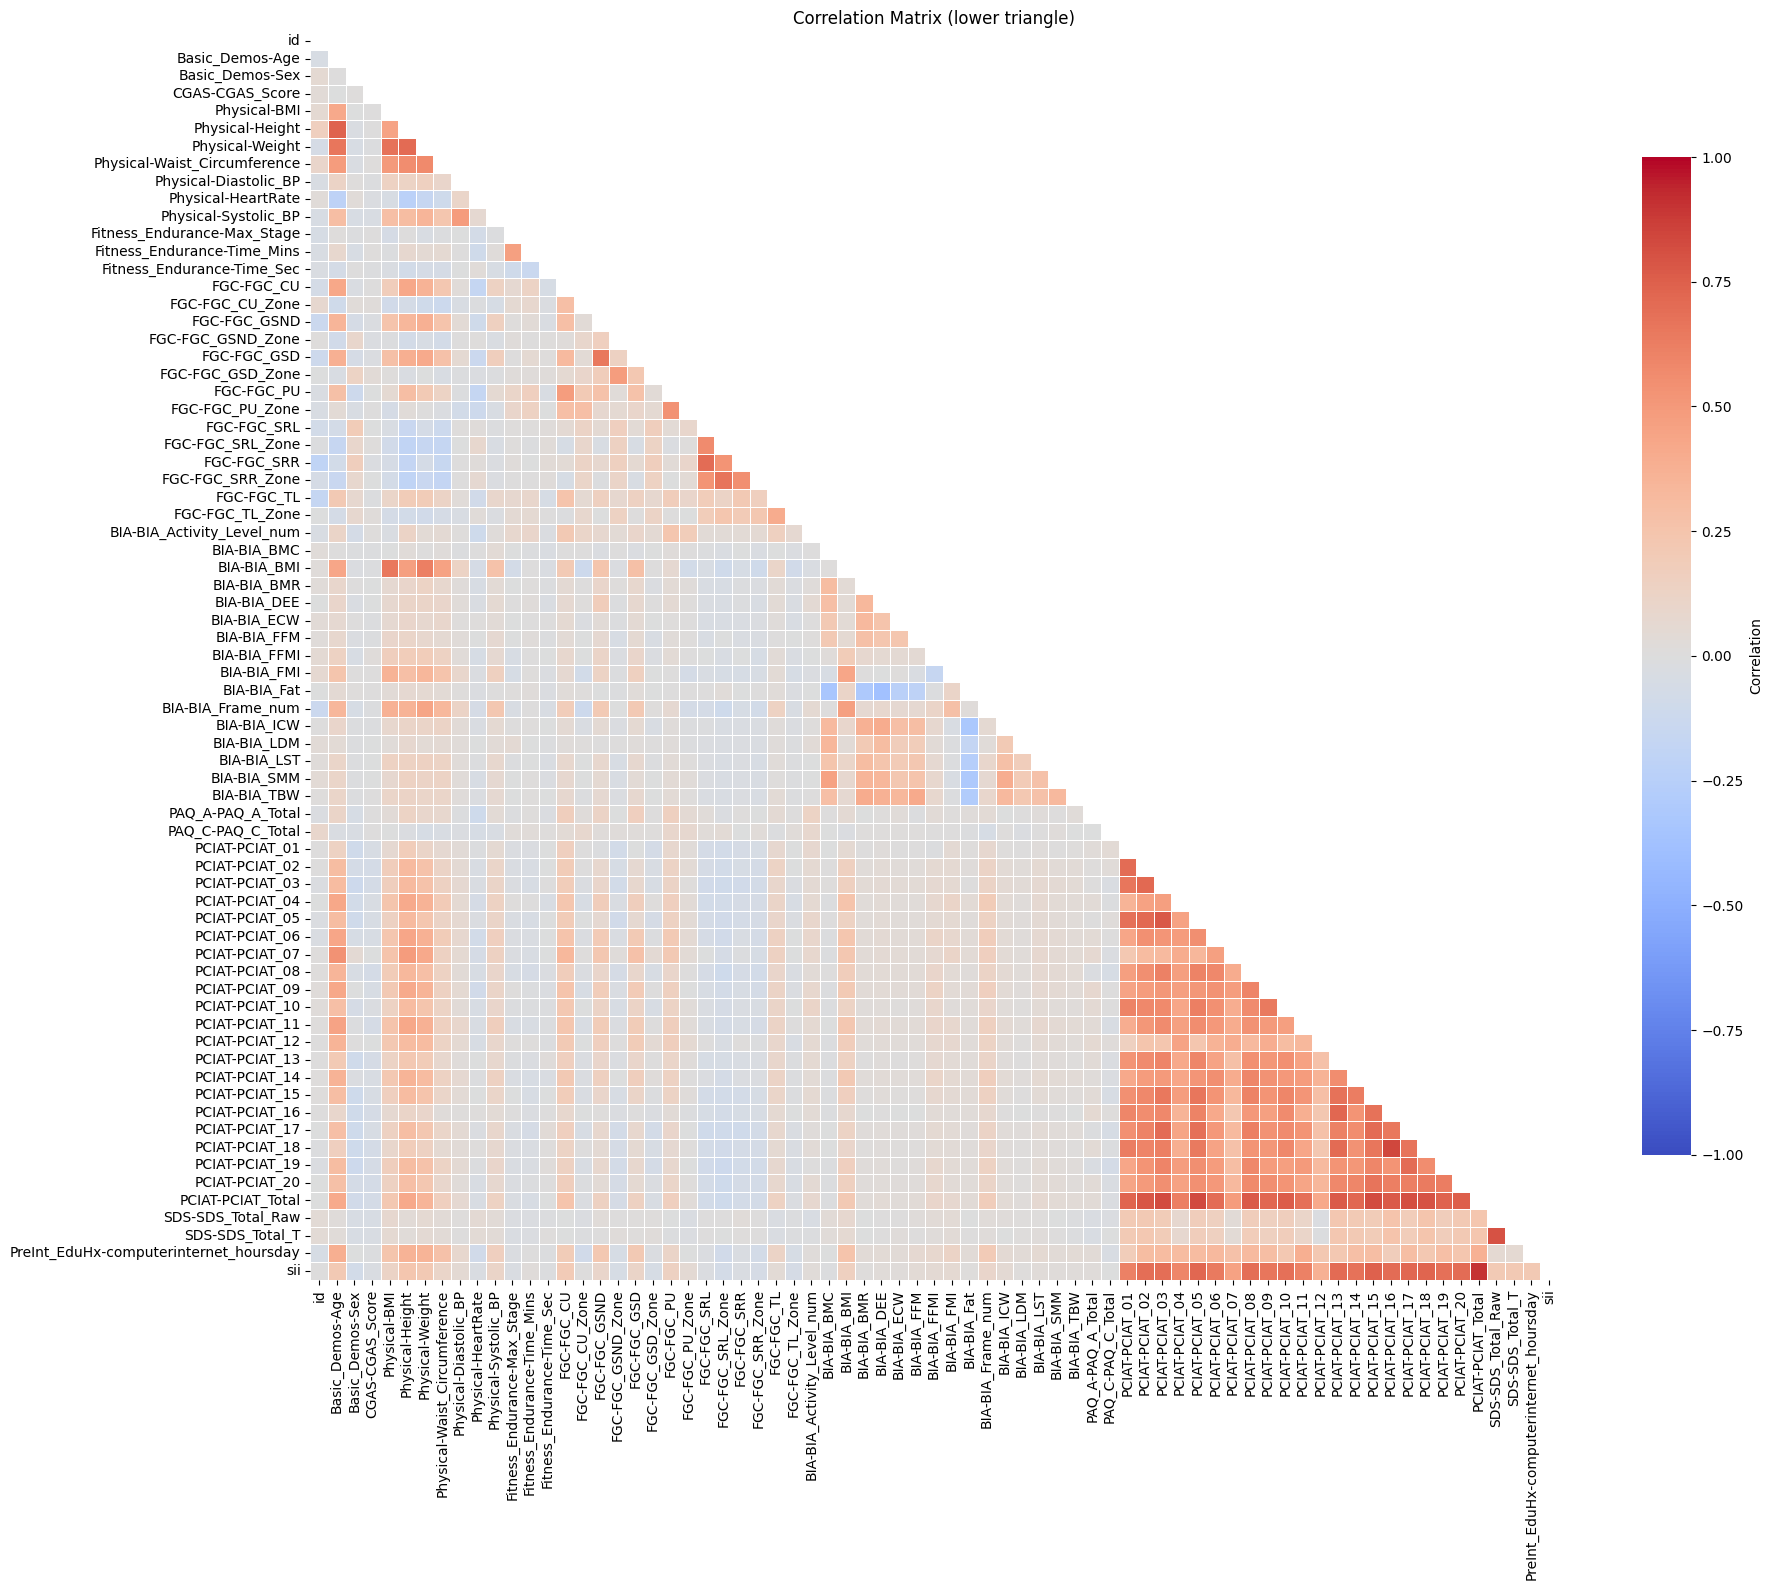

In [7]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

corr = df.select_dtypes(include='number').corr()

# Mask upper triangle (symmetric part)
mask = np.triu(np.ones_like(corr, dtype=bool))

plt.figure(figsize=(20, 16))
sns.heatmap(corr, mask=mask, cmap='coolwarm', center=0, vmin=-1, vmax=1,
            linewidths=0.5, fmt='.2f', square=True,
            cbar_kws={'label': 'Correlation', 'shrink': 0.8})
plt.title('Correlation Matrix (lower triangle)')
plt.tight_layout()
plt.show()

In [8]:
# Filter correlations with absolute value > 0.3 (excluding self-correlations)
strong = corr.where(np.triu(np.ones_like(corr, dtype=bool), k=1)).stack()
strong = strong[(strong > 0.3) | (strong < -0.3)].sort_values(ascending=False)

print(f"Correlations higher than 0.3 or lower than -0.3 ({len(strong)} pairs):\n")
print(strong.to_string())

Correlations higher than 0.3 or lower than -0.3 (334 pairs):

PCIAT-PCIAT_Total             sii                                       0.898571
PCIAT-PCIAT_16                PCIAT-PCIAT_18                            0.838446
PCIAT-PCIAT_05                PCIAT-PCIAT_Total                         0.830679
PCIAT-PCIAT_03                PCIAT-PCIAT_Total                         0.823338
PCIAT-PCIAT_15                PCIAT-PCIAT_Total                         0.823030
PCIAT-PCIAT_17                PCIAT-PCIAT_Total                         0.820101
PCIAT-PCIAT_18                PCIAT-PCIAT_Total                         0.801979
SDS-SDS_Total_Raw             SDS-SDS_Total_T                           0.800225
PCIAT-PCIAT_02                PCIAT-PCIAT_Total                         0.788100
PCIAT-PCIAT_03                PCIAT-PCIAT_05                            0.773888
PCIAT-PCIAT_13                PCIAT-PCIAT_Total                         0.771093
PCIAT-PCIAT_16                PCIAT-PCIAT_Total

In [25]:
# Derive BMI from Height and Weight: BMI = kg / m²
mask_bmi = df['Physical-BMI'].isna() & df['Physical-Weight'].notna() & df['Physical-Height'].notna()
df.loc[mask_bmi, 'Physical-BMI'] = df.loc[mask_bmi, 'Physical-Weight'] / (df.loc[mask_bmi, 'Physical-Height'] / 100) ** 2
print(f"Filled {mask_bmi.sum()} BMI values from Height and Weight")

# Derive Height from BMI and Weight: Height(cm) = 100 * sqrt(kg / BMI)
mask_height = df['Physical-Height'].isna() & df['Physical-BMI'].notna() & df['Physical-Weight'].notna()
df.loc[mask_height, 'Physical-Height'] = 100 * np.sqrt(df.loc[mask_height, 'Physical-Weight'] / df.loc[mask_height, 'Physical-BMI'])
print(f"Filled {mask_height.sum()} Height values from BMI and Weight")

# Derive Weight from BMI and Height: Weight(kg) = BMI * (Height(cm) / 100)²
mask_weight = df['Physical-Weight'].isna() & df['Physical-BMI'].notna() & df['Physical-Height'].notna()
df.loc[mask_weight, 'Physical-Weight'] = df.loc[mask_weight, 'Physical-BMI'] * (df.loc[mask_weight, 'Physical-Height'] / 100) ** 2
print(f"Filled {mask_weight.sum()} Weight values from BMI and Height")

print(f"\nRemaining missing — BMI: {df['Physical-BMI'].isna().sum()}, Height: {df['Physical-Height'].isna().sum()}, Weight: {df['Physical-Weight'].isna().sum()}")

Filled 451 BMI values from Height and Weight
Filled 446 Height values from BMI and Weight
Filled 417 Weight values from BMI and Height

Remaining missing — BMI: 418, Height: 419, Weight: 402


In [26]:
physical_cols = ['Physical-BMI', 'Physical-Height', 'Physical-Weight',
                 'Physical-Waist_Circumference', 'Physical-Diastolic_BP',
                 'Physical-HeartRate', 'Physical-Systolic_BP']

df[physical_cols] = df.groupby(['Basic_Demos-Age', 'Basic_Demos-Sex'])[physical_cols] \
    .transform(lambda x: x.fillna(x.median()))

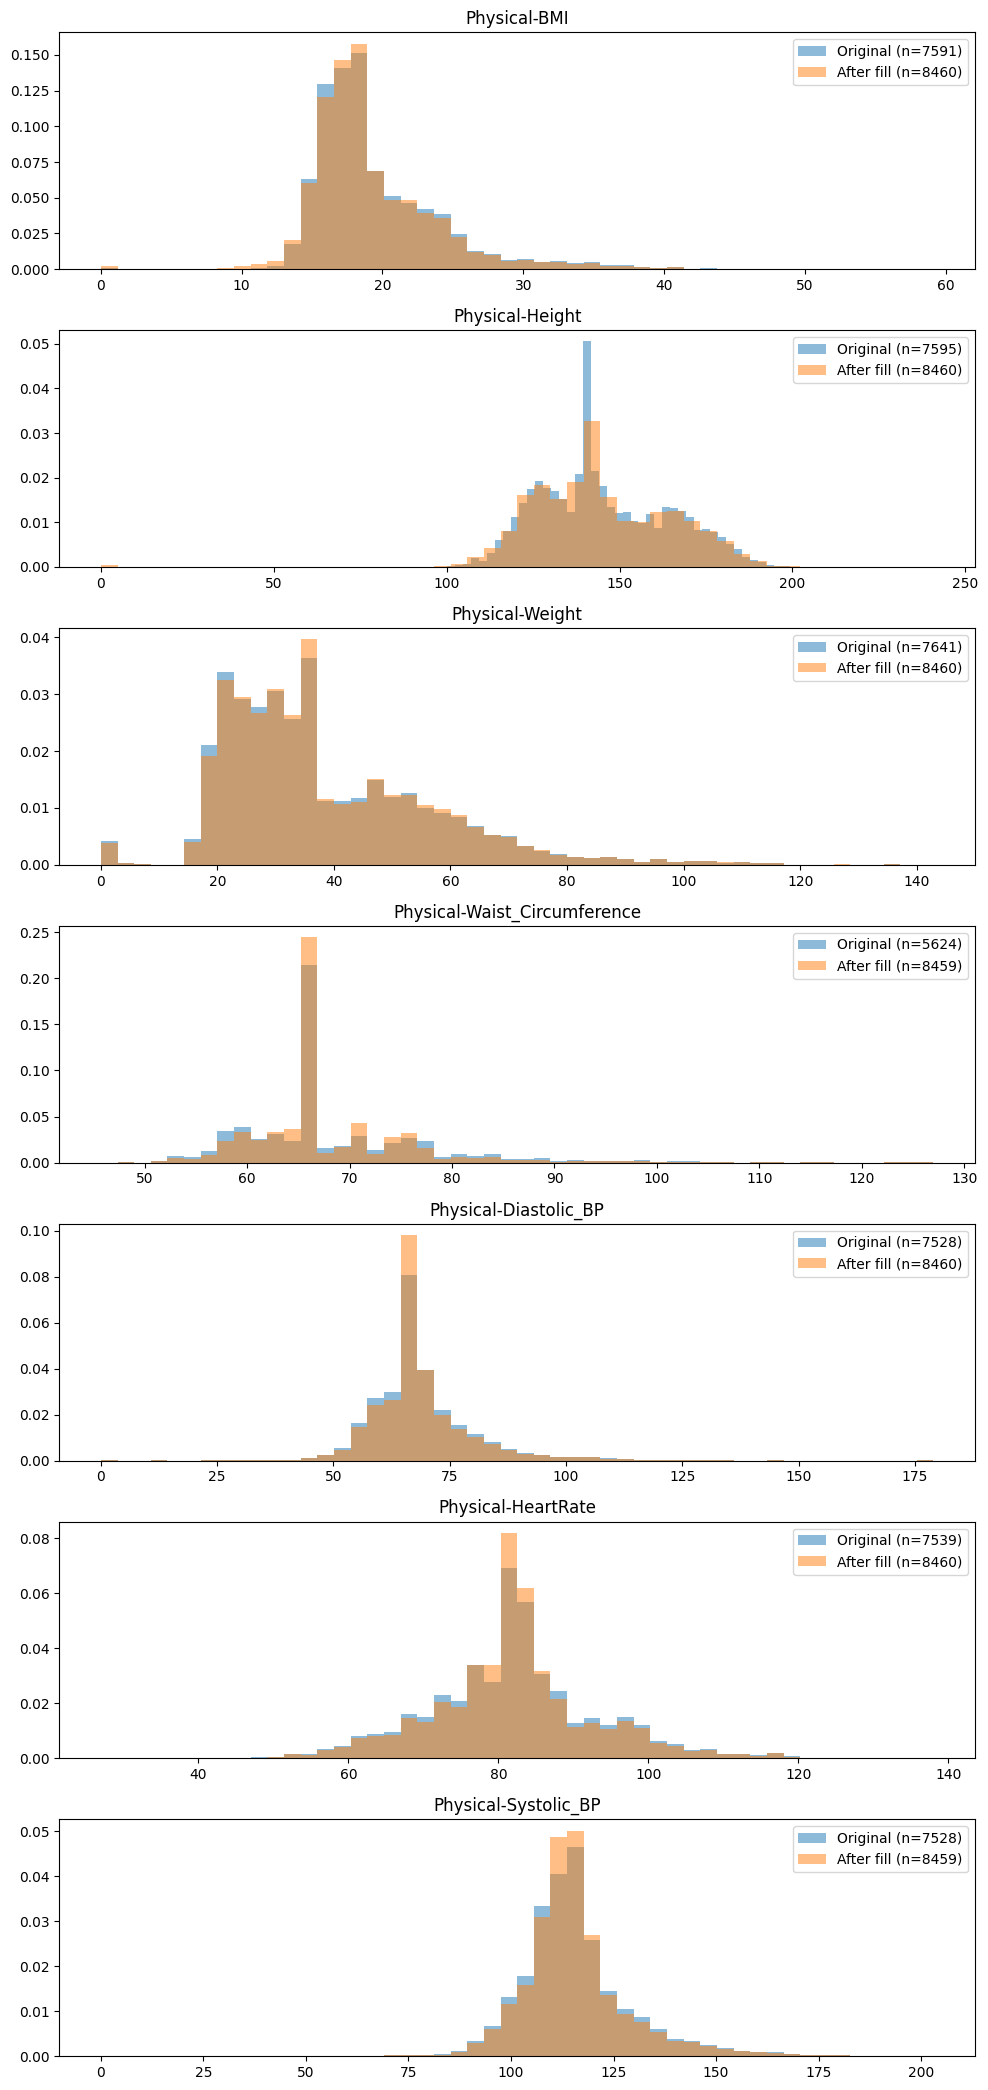

Column                               Orig mean  Fill mean   Orig std   Fill std
--------------------------------------------------------------------------------
Physical-BMI                             19.53      19.30       4.68       4.70
Physical-Height                         145.26     144.66      18.73      19.78
Physical-Weight                          38.30      38.56      18.24      18.05
Physical-Waist_Circumference             68.48      68.04       9.71       8.27
Physical-Diastolic_BP                    68.94      68.80      11.16      10.54
Physical-HeartRate                       81.89      81.85      11.38      10.77
Physical-Systolic_BP                    115.69     115.53      14.02      13.28


In [27]:
# Validate imputation: compare original vs filled distributions
df_original = pd.read_csv('data/cmi_internet.csv')
# Convert original to metric for fair comparison
df_original['Physical-Height'] = df_original['Physical-Height'] * 2.54
df_original['Physical-Weight'] = df_original['Physical-Weight'] * 0.453592
df_original['Physical-Waist_Circumference'] = df_original['Physical-Waist_Circumference'] * 2.54

check_cols = ['Physical-BMI', 'Physical-Height', 'Physical-Weight',
              'Physical-Waist_Circumference', 'Physical-Diastolic_BP',
              'Physical-HeartRate', 'Physical-Systolic_BP']

fig, axes = plt.subplots(len(check_cols), 1, figsize=(10, 3 * len(check_cols)))
for ax, col in zip(axes, check_cols):
    orig = df_original[col].dropna()
    filled = df[col].dropna()
    ax.hist(orig, bins=50, alpha=0.5, label=f'Original (n={len(orig)})', density=True)
    ax.hist(filled, bins=50, alpha=0.5, label=f'After fill (n={len(filled)})', density=True)
    ax.set_title(col)
    ax.legend()
plt.tight_layout()
plt.show()

# Summary stats comparison
print(f"{'Column':<35} {'Orig mean':>10} {'Fill mean':>10} {'Orig std':>10} {'Fill std':>10}")
print('-' * 80)
for col in check_cols:
    om, fm = df_original[col].mean(), df[col].mean()
    os, fs = df_original[col].std(), df[col].std()
    print(f"{col:<35} {om:>10.2f} {fm:>10.2f} {os:>10.2f} {fs:>10.2f}")